#

 Load data and define feature sets for the ablation

In [2]:
#import the libraries -Data manipulation

import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Make plots look nicer
sns.set_theme(style="whitegrid")

# Show plots in notebook
%matplotlib inline

In [4]:
# read in the df

model_df_binary = pd.read_parquet("../data/model_df_binary.parquet")

In [5]:
print(model_df_binary.columns.tolist())

['crime_id', 'month', 'reported_by', 'longitude', 'latitude', 'location', 'lsoa_code', 'lsoa_name', 'crime_type', 'last_outcome_category', 'outcome_binary', 'employ_score_rate', 'income_score_rate']


<Axes: xlabel='outcome_binary', ylabel='count'>

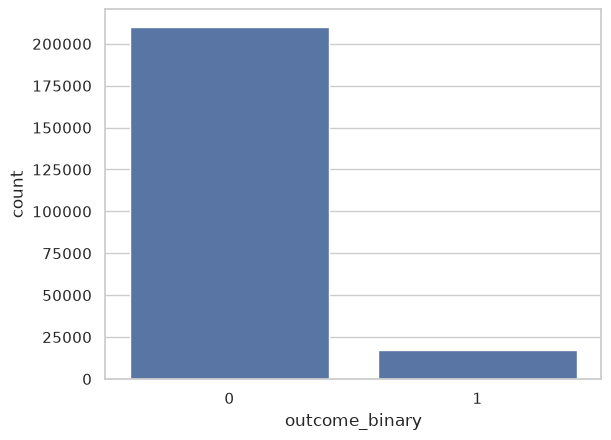

In [5]:
# more EDA on target or outcome variable - explore its distribution

sns.countplot(data=model_df_binary, x='outcome_binary')

In [7]:
model_df_binary['crime_type'].value_counts()

crime_type
Violence and sexual offences    108801
Public order                     21197
Criminal damage and arson        18690
Other theft                      17715
Vehicle crime                    14551
Shoplifting                      14422
Burglary                         12606
Other crime                       6159
Drugs                             5802
Robbery                           2912
Theft from the person             2217
Bicycle theft                     1488
Possession of weapons              998
Name: count, dtype: int64

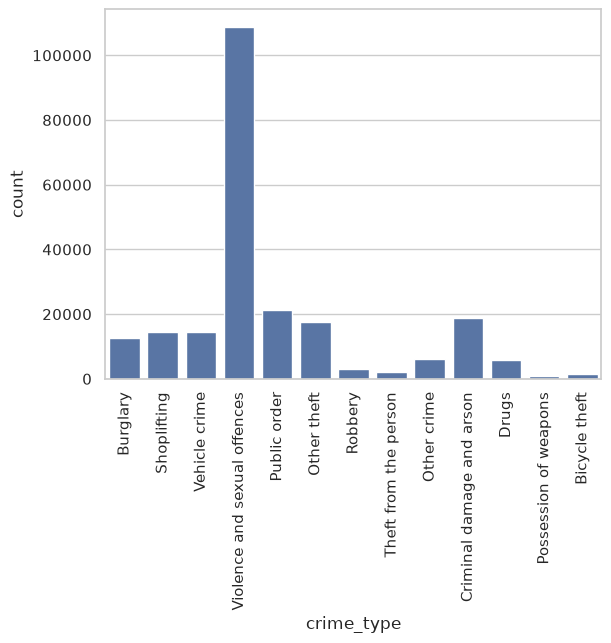

In [9]:
sns.countplot(data=model_df_binary, x='crime_type')
plt.xticks(rotation=90)
plt.show()

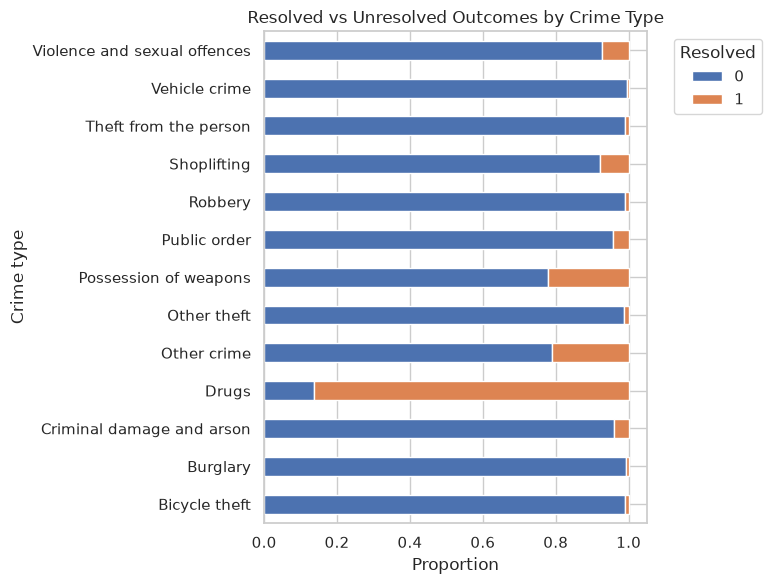

In [11]:
# which crimes are more likely to be resolved


ct = pd.crosstab(
    model_df_binary['crime_type'],
    model_df_binary['outcome_binary'],
    normalize='index'
)

ct.plot(kind='barh', stacked=True, figsize=(8, 6))
plt.xlabel('Proportion')
plt.ylabel('Crime type')
plt.title('Resolved vs Unresolved Outcomes by Crime Type')
plt.legend(title='Resolved', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Axes: xlabel='income_score_rate', ylabel='Count'>

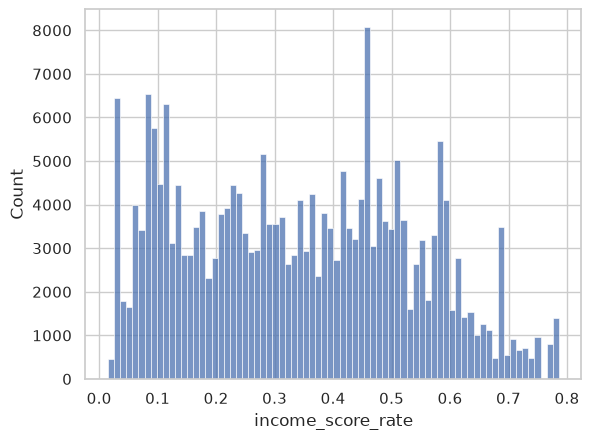

In [7]:
# Deprivation Analysis

sns.histplot(model_df_binary['income_score_rate'])


<Axes: xlabel='employ_score_rate', ylabel='Count'>

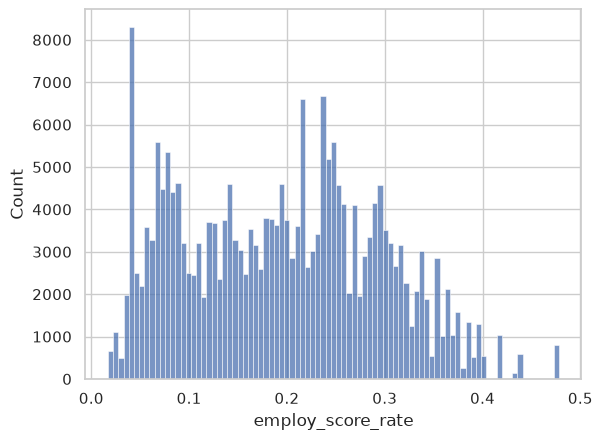

In [8]:
sns.histplot(model_df_binary['employ_score_rate'])

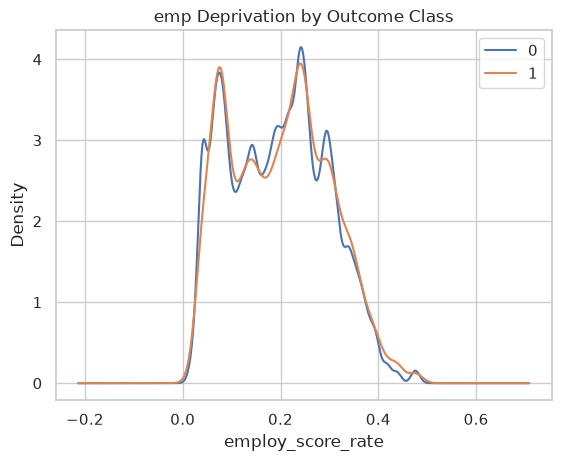

In [10]:


for outcome in model_df_binary['outcome_binary'].unique():
    subset = model_df_binary[model_df_binary['outcome_binary'] == outcome]
    subset['employ_score_rate'].plot(kind='kde', label=outcome)

plt.xlabel('employ_score_rate')
plt.title('emp Deprivation by Outcome Class')
plt.legend()
plt.show()

In [ ]:

RANDOM_STATE = 98

# Confirm shape and target balance before going further
print("Shape:", model_df_binary.shape)
print(model_df_binary['outcome_binary'].value_counts(normalize=True).round(4) * 100)

In [ ]:

# Crime-type one-hot columns + engineered month feature
crime_type_cols = [c for c in model_df_binary.columns if c.startswith('crime_type')] + ['month']



In [ ]:
# Deprivation predictors (continuous)
deprivation_cols = ['income_deprivation_score', 'employment_deprivation_score']

target_col = 'outcome_binary'

# Two feature sets for the ablation comparison
feature_sets = {
    'baseline_crime_type_only': crime_type_cols,
    'full_with_deprivation': crime_type_cols + deprivation_cols,
}

print("\nBaseline features:", len(crime_type_cols))
print("Full feature set:", len(crime_type_cols + deprivation_cols))